In [88]:

import seaborn as sns

import pandas as pd 

# import 'numpy' 
import numpy as np

# import subpackage of matplotlib
import matplotlib.pyplot as plt

# import 'seaborn'
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# import 'stats' package from scipy library
from scipy import stats

# import statistics to perform statistical computations
import statistics

# to test the normality 
from scipy.stats import shapiro

# import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# import the functions to perform Chi-square tests
from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import chisquare

# function to perform post-hoc test
import statsmodels.stats.multicomp as mc

# import function to perform post-hoc
# install scikit_posthocs using "!pip install scikit_posthocs" 
import scikit_posthocs


In [90]:
data = pd.DataFrame({'price' :[23, 30 ,20 ,27, 44 ,26 ,35 ,20 ,29 ,29,
25, 15, 18 ,27 ,19 ,22 ,12, 26, 34 ,15,
27, 35, 26 ,43, 35 ,14 ,24, 12 ,23, 31,
40, 35, 38, 57, 22 ,42 ,24, 21, 27 ,33]})
data

,price
0,23
1,30
2,20
3,27
4,44
5,26
6,35
7,20
8,29
9,29


In [194]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   price   40 non-null     int64
dtypes: int64(1)
memory usage: 384.0 bytes


In [5]:
missing_data_sum = data.isnull().sum()
missing_data = pd.DataFrame({'total_missing_values': missing_data_sum,'percentage_of_missing_values': (missing_data_sum/data.shape[0])*100})
missing_data

,total_missing_values,percentage_of_missing_values
price,0,0.0


<AxesSubplot:>

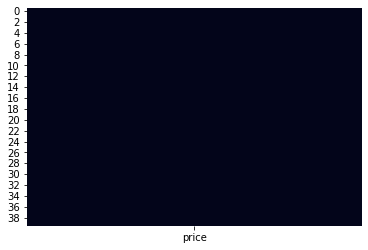

In [7]:
sns.heatmap(data.isnull(), cbar = False)

Out of 18 columns, only 6 columns have complete data. And columns such as 
waist , bust, shoe_size, show_width and hips are considerable percent of null values.

In [198]:
data.dtypes

price    int64
dtype: object

# Q1. Compute the mean, median and the mode of the data

In [6]:
data1 = data.mean()
data2= data.median()
data3 = data.mode()
print('Mean:','\n',round(data1,2))
print('Median:','\n',data2)
print('Mode:','\n',data3)

Mean: 
 price    27.62
dtype: float64
Median: 
 price    26.5
dtype: float64
Mode: 
    price
0     27
1     35


# Q.2 Compute the range , variance and standard deviation of the data

In [7]:
standard_deviation=np.std(data)
standard_deviation

price    9.501809
dtype: float64

In [8]:
variance=np.var(data)
variance

price    90.284375
dtype: float64

In [9]:
d1=min(data['price'])

d2=max(data['price'])
print('Range of data is',d1,'to',d2)

Range of data is 12 to 57


# Q3. Find the mean deviation for the data .

In [10]:
data.mad()

price    7.4
dtype: float64

# Q4. Calculate the Pearson coefficient of skewness and comment on the skewness of the data

In [11]:
def check(columns):
    mean = data.mean()
    median=data.median()
    sd=np.std(data)
    total = 3*(mean-median)/sd
    return total

In [12]:
ch=check(data)
ch

price    0.355196
dtype: float64

Skewness tells us the direction of outliers.
While all other variable are Positively skewd.

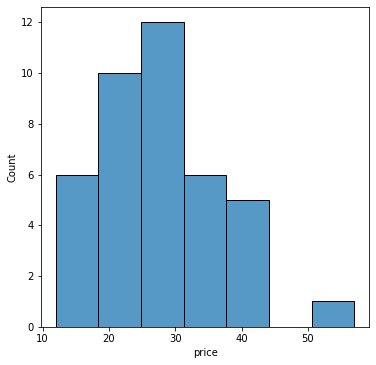

In [13]:
plt.figure(figsize=(20,20))
df_num= data.select_dtypes(include=np.number)
for i, column in enumerate(df_num.columns, 1):
    plt.subplot(3,3,i)
    sns.histplot(df_num[column])

# Q.5 Count the number of data values that fall within two standard deviations of the mean. Compare this with the answer from Chebyshev’s Theorem.


In [206]:
mean1=data.mean()

In [207]:
std1=data.std()

In [208]:
mean1+2*std1

price    46.870712
dtype: float64

In [14]:
quan = data.quantile(0.95)
print(quan)


price    43.05
Name: 0.95, dtype: float64


In [ ]:
Both answer are close to each other.

# Q6.Find the three quartiles and the interquartile range (IQR)


In [15]:
Q1=data.quantile(.25)
Q2=data.quantile(.50)
Q3=data.quantile(.75)
IQR=Q3-Q1
print('First Quantile:\n',Q1,'Second Quantile:\n',Q2,'Third Quantile\n',Q3,'IQR :',IQR)

First Quantile:
 price    21.75
Name: 0.25, dtype: float64 Second Quantile:
 price    26.5
Name: 0.5, dtype: float64 Third Quantile
 price    34.25
Name: 0.75, dtype: float64 IQR : price    12.5
dtype: float64


# Q7. Are there any outliers in the data set ?

In [18]:
import warnings
warnings.filterwarnings('ignore')

# Q8. Draw a boxplot of the dataset to confirm .

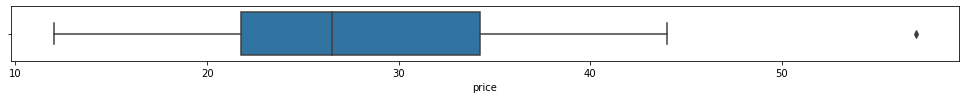

In [16]:
for column in df_num:
        plt.figure(figsize=(17,1))
        sns.boxplot(data=df_num, x=column)

In [ ]:
There is only one outlier.

# Q9. Find the percentile rank of the datapoint 25.

In [19]:
df = pd.DataFrame({'price' :[23, 30 ,20 ,27, 44 ,26 ,35 ,20 ,29 ,29,
25, 15, 18 ,27 ,19 ,22 ,12, 26, 34 ,15,
27, 35, 26 ,43, 35 ,14 ,24, 12 ,23, 31,
40, 35, 38, 57, 22 ,42 ,24, 21, 27 ,33]})
df

,price
0,23
1,30
2,20
3,27
4,44
5,26
6,35
7,20
8,29
9,29


In [20]:
data['Percentile Rank'] = data.price.rank(pct = True)
data

,price,Percentile Rank
0,23,0.3375
1,30,0.6750
2,20,0.2125
3,27,0.5625
4,44,0.9750
5,26,0.4750
6,35,0.8125
7,20,0.2125
8,29,0.6375
9,29,0.6375


# Q10.What is the probability that a shirt cost is above 25 dollars?


In [21]:
num=len(df[df['price']>25])
den=len(df['price'])
probability=num/den
print('probability that a shirt cost is above 25 dollars is:',probability)

probability that a shirt cost is above 25 dollars is: 0.575


# Q11.Create a frequency distribution for the data and visualize it appropriately

<AxesSubplot:xlabel='price'>

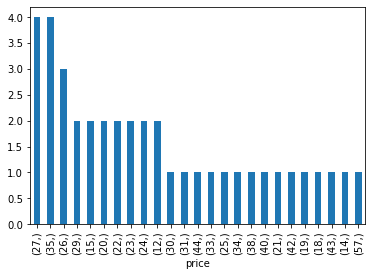

In [22]:
data2= df.value_counts()
data2.plot(kind='bar')

# Q12. Create a probability distribution of the data and visualize it appropriately.

<AxesSubplot:xlabel='prob', ylabel='Density'>

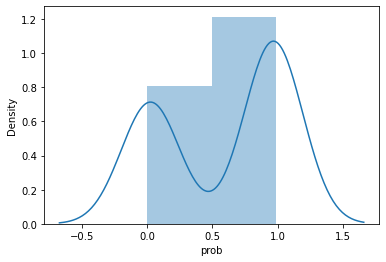

In [23]:
mu = np.mean(df.price)
sig = df.price.std()
df['prob'] = 0.0

for idx,row in df.iterrows():
    if row.price < mu:
        df.at[idx,'prob'] = 1 - (stats.norm(mu,sig).pdf(row.price))
    else:
        df.at[idx,'prob'] = stats.norm(mu, sig).pdf(row.price)
sns.distplot(df['prob'])


# Q13. What is the shape of the distribution of this dataset? Create an appropriate graph to determine that. Take 100 random samples with replacement from this dataset of size 5 each. Create a sampling distribution of the mean shirt prices. Compare with other sampling distributions of sample size 10, 15, 20, 25, 30. State your observations. Does it corroborate the Central Limit Theorem?

<AxesSubplot:xlabel='price', ylabel='Count'>

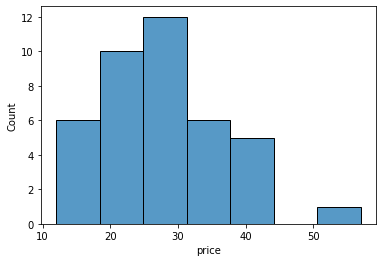

In [39]:
sns.histplot(df['price'])

In [ ]:
A distribution is said to be positively skewed when the tail on the right side of the histogram is longer than the 
left side. Most of the values tend to cluster toward the left side of the x-axis (i.e. the smaller values)
with increasingly fewer values at the right side of the x-axis (i.e. the larger values).



[22.6, 31.4, 19.6, 27.8, 28.8, 28.4, 22.6, 23.2, 40.4, 25.0, 31.4, 28.6, 26.0, 23.6, 21.6, 30.8, 24.2, 27.8, 32.2, 24.2, 25.6, 22.0, 26.8, 27.0, 28.8, 27.2, 27.6, 26.4, 25.0, 25.2, 14.4, 27.6, 30.8, 26.2, 29.8, 25.0, 31.4, 35.6, 26.0, 24.8, 29.8, 30.8, 29.6, 32.0, 19.4, 30.8, 21.6, 26.2, 31.6, 23.8, 21.8, 22.8, 20.4, 28.6, 31.2, 22.4, 32.4, 29.6, 32.8, 19.2, 31.4, 40.8, 19.8, 26.6, 26.0, 35.4, 19.2, 28.6, 27.4, 23.4, 27.0, 24.2, 19.4, 28.8, 27.0, 28.0, 25.6, 25.2, 27.2, 27.8, 23.0, 37.4, 27.6, 21.2, 28.2, 32.4, 24.4, 26.2, 18.4, 28.4, 31.8, 22.4, 27.8, 34.0, 29.2, 33.6, 33.0, 28.4, 32.4, 36.0]


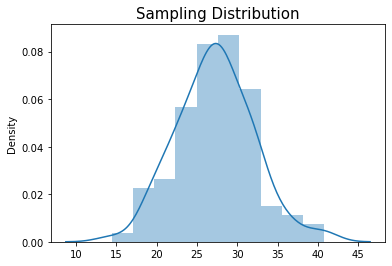

In [24]:

sample_size = 5  #n
n_samples=100
population_array=df['price']
# create an empty list to store the means of each sample
sample_means = []
for i in range(n_samples):
    # generates a random sample of size 100 from the population array
    sample = np.random.choice(population_array, size=sample_size, replace=True)
    sample_mean = np.mean(sample)        # calculate the mean of the sample data
    sample_means.append(sample_mean)     # append the mean to the list
print(sample_means)   
sns.distplot(sample_means)
plt.title("Sampling Distribution", fontsize=15)
plt.show()

# Q14. Treat this dataset as a binomial distribution where p is the probability that a shirt costs above 25 dollars. What is the probability that out of a random sample of 10 shirts 7 are costing more than 25 dollars

In [214]:
data2= data['price']>25
data2=len(data2)/len(data)
p=data2
n=10
x=7
prob4=stats.binom.sf(7,10,data2)
print('The probability that out of a random sample of 10 shirts 7 are costing more than 25 dollars is :',prob4)




The probability that out of a random sample of 10 shirts 7 are costing more than 25 dollars is : 1.0


# Q15. NuCloth Claims that 60% of all shirts in their website cost less than 25 dollars . Using the Normal approximation of a Binomial distribution, find the probability that in a random sample of 10 shirts 7 of them will cost less than 25 dollars.[ Note that the normal distribution can be used to approximate a binomial distribution if np>=5 and nq>=5 with the following correction for continuityP(X=z) = P(z-0.5 < X < z+0.5 ) ]

In [42]:
p=0.60
n=10
x=7
prob5= stats.binom.cdf(7,10,0.60)
print('find the probability that in a random sample of 10 shirts 7 of them will cost less than 25 dollars is:',prob5)

find the probability that in a random sample of 10 shirts 7 of them will cost less than 25 dollars is: 0.8327102464


# Q16.Compute a 95% Confidence Interval for the true price of a shirt in the NuCloth website using appropriate distribution.( State reasons as to why did you use a z or t distribution)

In [47]:
x_bar = np.mean(df['price'])
n = len(df['price'])
sigma = np.std(df['price'],ddof=1)
alpha = 0.05

z_alpha_by_2 = stats.norm.isf(0.05/2)
print(z_alpha_by_2)
upper = x_bar + z_alpha_by_2 * sigma / n**0.5
lower = x_bar - z_alpha_by_2 * sigma / n**0.5
print('95% Confidence interval for true price of shirt is:', lower, upper)

1.9599639845400545
95% Confidence interval for true price of shirt is: 24.642900805126224 30.607099194873776


# Q17. A data scientist wants to estimate with 95% confidence the true proportion of shirts having price greater than 25 dollars in the NuCloth website. A recent study showed that 60% of all shirts have a price greater than 25 dollars. The data scientist wants to be accurate within 2% of the true proportion. Find the minimum sample size necessary.

In [161]:
sigma =0.60
margin_of_error = 0.02
alpha = 0.05

z_alpha_by_2 = stats.norm.isf(0.05/2)

# calculate sample size (n) 
n =(z_alpha_by_2*sigma/margin_of_error )**2
print('Required Sample Size:', round(n))

Required Sample Size: 3457


# Q18.The same data scientist wants to estimate the true proportion of shirts having price greater than 25 dollars. She wants to be 90% confident and accurate within 5% of true proportion. Find the minimum sample size necessary

In [220]:
# calculate sample size using the margin of error
sigma =np.std(data['price']>25)
print(sigma)

margin_of_error = 0.05
alpha = 0.1

z_alpha_by_2 = stats.norm.isf(0.1/2)

# calculate sample size (n) 
n =(z_alpha_by_2*sigma/margin_of_error )**2
print('Required Sample Size:', round(n))

0.4943429983321297
Required Sample Size: 264


In [219]:
# calculate sample size using the margin of error
sigma =0.60

margin_of_error = 0.05
alpha = 0.1

z_alpha_by_2 = stats.norm.isf(0.1/2)

# calculate sample size (n) 
n =(z_alpha_by_2*sigma/margin_of_error )**2
print('Required Sample Size:', round(n))

Required Sample Size: 390


# Q19 NuCloth claims that currently 80% of all shirts have prices greater than 25 dollars . Test this claim with an alpha =0.05 if out of a random sample of 30 shirts only 23 are having prices above 25 dollars

In [170]:
#H0:mu=80
#H1:mu<0.80
hypo_p=0.8
x=23
n=30
p_samp=x/n
z_stat=(p_samp-hypo_p)/np.sqrt((hypo_p*(1-hypo_p))/n)
p_val=stats.norm.sf(z_stat)
print('Test stat',z_stat)
print(p_val)

Test stat -0.45643546458763834
0.6759615659304269


In [ ]:
As p_value >alpha(0.05) we fail to reject null hypothesis ,hence 80% of shirts have prices greater than 25.

# Q20. A data scientist is researching the hypothesis that the average price of a shirt in NuCloth is higher than the supermarket. So he collects data from NuCloth and the supermarket that the average shirt price of shirts in NuCloth is 36 dollars vs 34 dollars in the supermarket. The standard deviations are 7.6 and 5.8 respectively.Suppose the data scientist got these values after randomly selecting 100 shirts from each place.a. What hypothesis would he use to compare the shirt prices of NuCloth vsSupermarketb. What are critical values to be used?c. What statistical test will be used to compare these prices?d. Complete the test and obtain the P-value.e. Summarize his conclusion based on the P-value

H0:mu_of_NuCloth-mu_of_supermarket<=0

H1:mu_of_NuCloth-mu_of_supermarket>0

In [11]:
x1_bar=36
x2_bar=34
s1=7.6
s2=5.8
n1=100
n2=100
null_value=0
denominator = np.sqrt((s1**2 / n1) + (s2**2 / n2))
zscore = ((x1_bar - x2_bar) - (null_value)) / denominator
print('z-score:', zscore)


z-score: 2.09197696327652


In [9]:
z_critical = round(stats.norm.isf(0.05/2), 2)
z_critical

1.96

In [ ]:
As Zstat is > z_critical so we reject H0


In [12]:
p_val=stats.norm.sf(zscore)
p_val

0.018220288245112185

In [ ]:
As p_val < alpha(0.05) Hence we reject null Hypothesis so the claim of Data scientist that average price of Nucloth Shirt 
is more than Supermarket is correct.

# .# STATS MINI Project

In [218]:
data1 = pd.read_json('C:\\Users\\Dell\\Desktop\\zip open\\project 4\\modcloth_final_data.json',lines=True)
data1.head()

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


# Q1Read the datasets, Check the data types and Change the data types appropriately.


In [15]:
data1.dtypes

item_id             int64
waist             float64
size                int64
quality           float64
cup size           object
hips              float64
bra size          float64
category           object
bust               object
height             object
user_name          object
length             object
fit                object
user_id             int64
shoe size         float64
shoe width         object
review_summary     object
review_text        object
dtype: object

In [69]:
data1['height']

0        5ft 6in
1        5ft 2in
2        5ft 7in
3            NaN
4        5ft 2in
          ...   
82785    5ft 8in
82786    5ft 5in
82787    5ft 4in
82788    5ft 3in
82789        6ft
Name: height, Length: 82790, dtype: object

# Q2.Change the height column datatype to float after converting the values 

In [16]:
data1['height'].replace(np.nan,'5ft 4in',inplace= True)

In [10]:
data1['height']=data1['height'].str.replace('\D','.')

In [17]:
def height_in_cms(ht):
    if ht != 'NaN':
        ht = ht.replace('ft','').replace('in', '')
        h_ft = int(ht.split()[0])
        if len(ht.split()) > 1:
            h_inch = int(ht.split()[1])
        else:
            h_inch = 0
        h_inch += h_ft * 12
        h_cm = round(h_inch * 2.54, 1)
        return h_cm
data1['height'] = data1['height'].apply(height_in_cms)
data1.head()

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,167.6,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,157.5,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,170.2,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,162.6,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,157.5,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [11]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  object 
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  object 
 8   bust            11854 non-null  object 
 9   height          82790 non-null  object 
 10  user_name       82790 non-null  object 
 11  length          82755 non-null  object 
 12  fit             82790 non-null  object 
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  object 
 16  review_summary  76065 non-null  object 
 17  review_text     76065 non-null 

# Q3. Rename the names of the columns which have space in between the column.Ex: shoe size as shoe_size etc.


In [18]:
data1.rename(columns = {'cup size':'cup_size', 'bra size':'bra_size',
                              'shoe size': 'shoe_size','shoe width':'shoe_width'}, inplace = True)
data1.head()

,item_id,waist,size,quality,cup_size,hips,bra_size,category,bust,height,user_name,length,fit,user_id,shoe_size,shoe_width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,167.6,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,157.5,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,170.2,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,162.6,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,157.5,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


# 4. Check the missing values and Identify the distribution of the variables to impute the missing values. Explain based on your analysis decide the features which can be dropped and Which can be imputed. And also explain the reason to choose the metric that you have chosen to impute the null values.Note: Kindly copy the datasets and work on the new data frame.4.1 Check the count and percentage of missing values.4.2 check the Mean and Median.54.3 Check the distribution of the variables using Histogram or Dist plot or KDE and boxplot etc.Kindly explore at least two.


In [19]:
missing_data_sum = data1.isnull().sum()
missing_data = pd.DataFrame({'total_missing_values': missing_data_sum,'percentage_of_missing_values': (missing_data_sum/data1.shape[0])*100})
missing_data

,total_missing_values,percentage_of_missing_values
item_id,0,0.000000
waist,79908,96.518903
size,0,0.000000
quality,68,0.082136
cup_size,6255,7.555260
hips,26726,32.281677
bra_size,6018,7.268994
category,0,0.000000
bust,70936,85.681846
height,0,0.000000


In [20]:
data1.drop(['item_id','waist','bust' ,'user_id'], axis=1, inplace=True)


In [13]:
data1

,size,quality,cup_size,hips,bra_size,category,height,user_name,length,fit,shoe_size,shoe_width,review_summary,review_text
0,7,5.0,d,38.0,34.0,new,167.6,Emily,just right,small,NaN,NaN,NaN,NaN
1,13,3.0,b,30.0,36.0,new,157.5,sydneybraden2001,just right,small,NaN,NaN,NaN,NaN
2,7,2.0,b,NaN,32.0,new,170.2,Ugggh,slightly long,small,9.0,NaN,NaN,NaN
3,21,5.0,dd/e,NaN,NaN,new,162.6,alexmeyer626,just right,fit,NaN,NaN,NaN,NaN
4,18,5.0,b,NaN,36.0,new,157.5,dberrones1,slightly long,small,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82785,8,4.0,b,NaN,36.0,outerwear,172.7,Jennifer,just right,fit,8.5,average,Cute jacket!,Cute jacket!
82786,12,5.0,ddd/f,NaN,34.0,outerwear,165.1,Kelli,slightly long,small,NaN,NaN,It's a beautiful jacket.,It's a beautiful jacket. I love how it's knit ...
82787,12,5.0,dddd/g,36.0,32.0,outerwear,162.6,elacount,just right,fit,NaN,NaN,I love this blazer. It is,I love this blazer. It is a great office piece...
82788,12,4.0,NaN,NaN,NaN,outerwear,160.0,jennaklinner,just right,fit,NaN,NaN,I love this blazer!! I wo,I love this blazer!! I wore it yesterday and g...


In [ ]:
As we can see 'waist','bust' ,'shoe_size','shoe_width' have higher number of values so we drop those columns.
and User_id ,item_id are PII that do not have any analysis effect.

In [21]:
4.1
data1['length'].replace(np.nan,' just right',inplace= True)
data1['cup_size'].replace(np.nan,'c',inplace= True)
data1['quality'].replace(np.nan,data1['quality'].median(),inplace= True)
data1['bra_size'].replace(np.nan,data1['bra_size'].median(),inplace= True)
data1['hips'].replace(np.nan,data1['hips'].mean(),inplace= True)
data1['shoe_size'].replace(np.nan,data1['shoe_size'].mean(),inplace= True)



In [15]:

data1 = data1.copy(deep=True)
data1

,size,quality,cup_size,hips,bra_size,category,height,user_name,length,fit,shoe_size,shoe_width,review_summary,review_text
0,7,5.0,d,38.000000,34.0,new,167.6,Emily,just right,small,8.145818,NaN,NaN,NaN
1,13,3.0,b,30.000000,36.0,new,157.5,sydneybraden2001,just right,small,8.145818,NaN,NaN,NaN
2,7,2.0,b,40.358501,32.0,new,170.2,Ugggh,slightly long,small,9.000000,NaN,NaN,NaN
3,21,5.0,dd/e,40.358501,36.0,new,162.6,alexmeyer626,just right,fit,8.145818,NaN,NaN,NaN
4,18,5.0,b,40.358501,36.0,new,157.5,dberrones1,slightly long,small,8.145818,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82785,8,4.0,b,40.358501,36.0,outerwear,172.7,Jennifer,just right,fit,8.500000,average,Cute jacket!,Cute jacket!
82786,12,5.0,ddd/f,40.358501,34.0,outerwear,165.1,Kelli,slightly long,small,8.145818,NaN,It's a beautiful jacket.,It's a beautiful jacket. I love how it's knit ...
82787,12,5.0,dddd/g,36.000000,32.0,outerwear,162.6,elacount,just right,fit,8.145818,NaN,I love this blazer. It is,I love this blazer. It is a great office piece...
82788,12,4.0,c,40.358501,36.0,outerwear,160.0,jennaklinner,just right,fit,8.145818,NaN,I love this blazer!! I wo,I love this blazer!! I wore it yesterday and g...


In [22]:
#4.1
missing_data_sum = data1.isnull().sum()
missing_data = pd.DataFrame({'total_missing_values': missing_data_sum,'percentage_of_missing_values': (missing_data_sum/data1.shape[0])*100})
missing_data

,total_missing_values,percentage_of_missing_values
size,0,0.000000
quality,0,0.000000
cup_size,0,0.000000
hips,0,0.000000
bra_size,0,0.000000
category,0,0.000000
height,0,0.000000
user_name,0,0.000000
length,0,0.000000
fit,0,0.000000


In [23]:
#4.2
print("mean of the dataset:",data1.mean())
print("median of the dataset:",data1.median())

mean of the dataset: size          12.661602
quality        3.949100
hips          40.358501
bra_size      35.974151
height       165.434202
shoe_size      8.145818
dtype: float64
median of the dataset: size          12.000000
quality        4.000000
hips          40.358501
bra_size      36.000000
height       165.100000
shoe_size      8.145818
dtype: float64


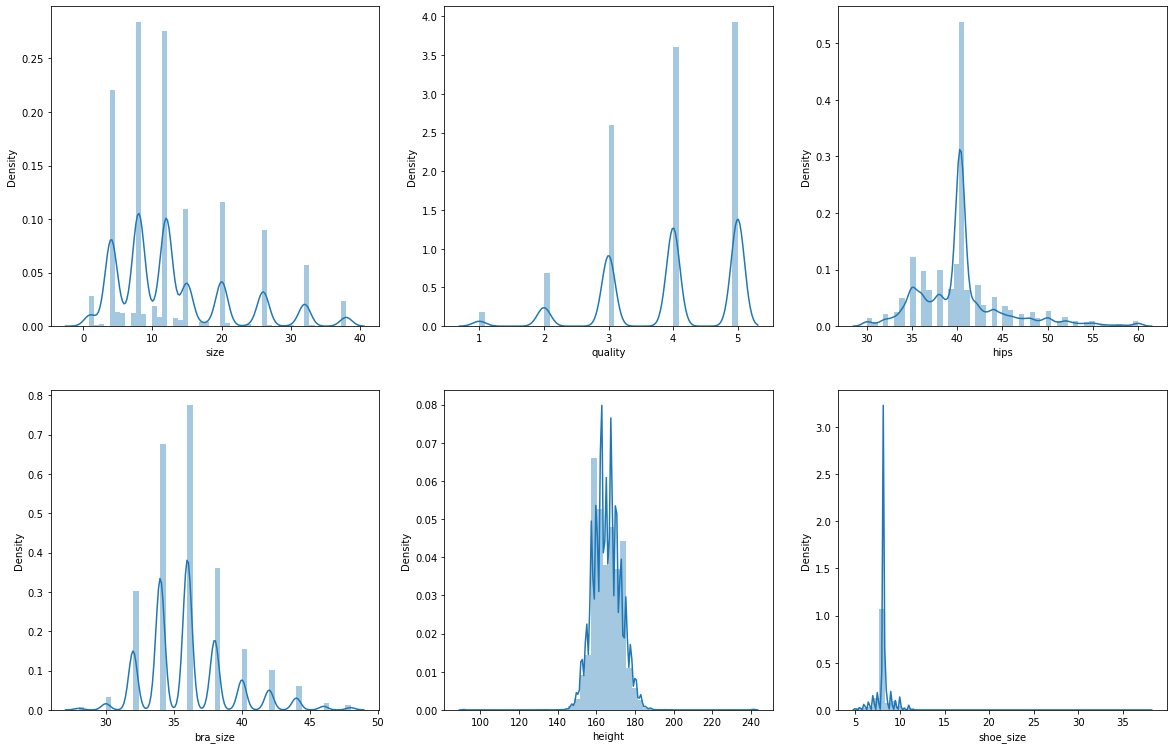

In [24]:
#4.3
plt.figure(figsize=(20,20))
df_num= data1.select_dtypes(include=np.number)
for i, column in enumerate(df_num.columns, 1):
    plt.subplot(3,3,i)
    sns.distplot(df_num[column])

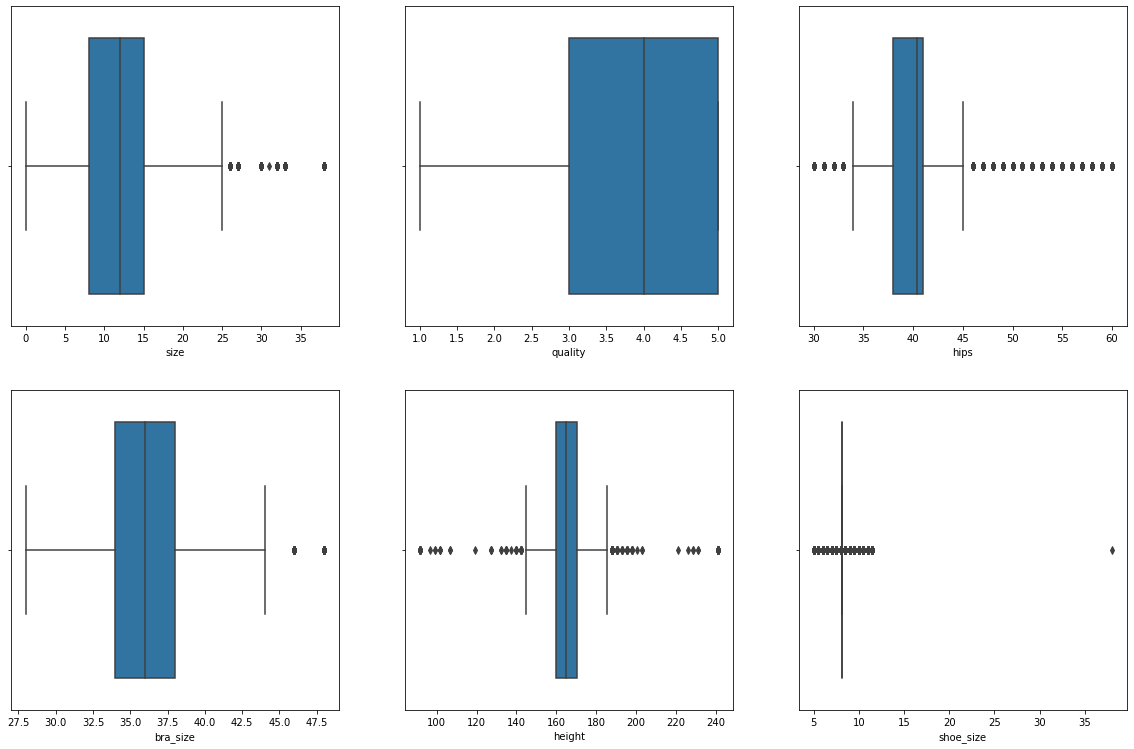

In [25]:
plt.figure(figsize=(20,20))
df_num= data1.select_dtypes(include=np.number)
for i, column in enumerate(df_num.columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(df_num[column])

In [ ]:
 outliers present in size,hips,bra size,height,shoe_size .only one variable quality has no Ouliers.

In [22]:
data1['height']

0        167.6
1        157.5
2        170.2
3        162.6
4        157.5
         ...  
82785    172.7
82786    165.1
82787    162.6
82788    160.0
82789    182.9
Name: height, Length: 82790, dtype: float64

In [ ]:
The variable size,hips,bra-size,height have outliers .

# 4.4 Check the Skewness and Kurtosis.Explain what the Skewness and Kurtosis describ

In [26]:
data1.skew()

size         1.128301
quality     -0.677180
hips         1.177744
bra_size     0.933685
height       0.226642
shoe_size    0.752058
dtype: float64

In [ ]:
Skewness is a measure of symmetry, or more precisely, the lack of symmetry. 
In data quality is negetively skewd,all other variables positively skewed.

In [27]:
data1.kurt()

size          0.760010
quality      -0.164654
hips          2.683011
bra_size      1.353599
height        6.197429
shoe_size    30.951600
dtype: float64

In [ ]:
Kurtosis refers to the degree of presence of outliers in the distribution.
Kurtosis is a statistical measure, whether the data is heavy-tailed or light-tailed in a normal distribution.

# Q5Find the outliers which are below and above 2.5 * IQR - Q1 and 2.5 * IQR + Q3.


In [227]:
q1=df_num.quantile(0.25)
q3=df_num.quantile(0.75)
IQR=q3-q1
lf=2.5*IQR-q1
print(lf)
hf=2.5*IQR+q3
print(hf)
data2 = df_num[(df_num<lf) | (df_num>hf)]
data2

size           9.500000
quality        2.000000
hips         -30.500000
bra_size     -24.000000
height      -134.500000
shoe_size     -8.145818
dtype: float64
size          32.500000
quality       10.000000
hips          48.500000
bra_size      48.000000
height       195.700000
shoe_size      8.145818
dtype: float64


,size,quality,hips,bra_size,height,shoe_size
0,7.0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,NaN,NaN,NaN,NaN,9.0
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
82785,8.0,NaN,NaN,NaN,NaN,8.5
82786,NaN,NaN,NaN,NaN,NaN,NaN
82787,NaN,NaN,NaN,NaN,NaN,NaN
82788,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
data1['review_summary'].value_counts()

Love it!                     185
I absolutely love this dr    124
Love it                       92
I really wanted to love t     92
I love this dress so much     84
                            ... 
Awesome weekend shirt wit      1
I love the shape and line      1
This is a cute tee that f      1
i am OBSESSED with this d      1
Bombshell Dress                1
Name: review_summary, Length: 61713, dtype: int64

In [30]:
data1

,size,quality,cup_size,hips,bra_size,category,height,user_name,length,fit,shoe_size,shoe_width,review_summary,review_text
0,7,5.0,d,38.000000,34.0,new,167.6,Emily,just right,small,8.145818,NaN,NaN,NaN
1,13,3.0,b,30.000000,36.0,new,157.5,sydneybraden2001,just right,small,8.145818,NaN,NaN,NaN
2,7,2.0,b,40.358501,32.0,new,170.2,Ugggh,slightly long,small,9.000000,NaN,NaN,NaN
3,21,5.0,dd/e,40.358501,36.0,new,162.6,alexmeyer626,just right,fit,8.145818,NaN,NaN,NaN
4,18,5.0,b,40.358501,36.0,new,157.5,dberrones1,slightly long,small,8.145818,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82785,8,4.0,b,40.358501,36.0,outerwear,172.7,Jennifer,just right,fit,8.500000,average,Cute jacket!,Cute jacket!
82786,12,5.0,ddd/f,40.358501,34.0,outerwear,165.1,Kelli,slightly long,small,8.145818,NaN,It's a beautiful jacket.,It's a beautiful jacket. I love how it's knit ...
82787,12,5.0,dddd/g,36.000000,32.0,outerwear,162.6,elacount,just right,fit,8.145818,NaN,I love this blazer. It is,I love this blazer. It is a great office piece...
82788,12,4.0,c,40.358501,36.0,outerwear,160.0,jennaklinner,just right,fit,8.145818,NaN,I love this blazer!! I wo,I love this blazer!! I wore it yesterday and g...


# Q 6. Check for the category dress review and visualize the top 10 reviews using any relevant plot. Identify the negative reviews if there are any

<AxesSubplot:>

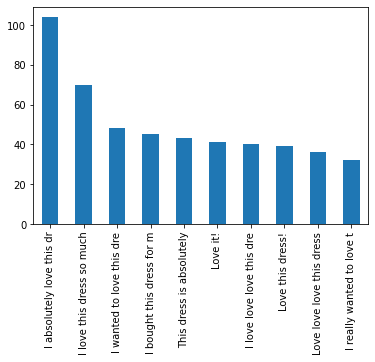

In [87]:
df=data1[data1['category']=='dresses']['review_summary'].value_counts().head(10)
df.plot(kind='bar')


there are no negetive reviews in top 10 review.

There is something wrong with the Question 

In [84]:
data1['review_summary'].replace(np.nan,'Love it!',inplace= True)

In [56]:
df1['review_summary'].replace(np.nan,'Love it!',inplace= True)


# Q7.Find out the average shoe size for the different fits of the customer. Visualize using any relevant plot. Explain that, Is there any significant different shoe sizes for different fits?

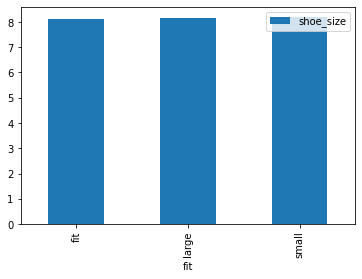

In [30]:
piv1=pd.pivot_table(data1,index=['fit'],values=['shoe_size']).plot(kind='bar')

# 8. Identify the customer’s common shoe width and average size for those who purchased the maximum quality. Is the mode of shoe width affect the user review?Visualize using the appropriate plot.

In [67]:
df1

,size,quality,hips,bra_size,height,shoe_size
0,7,5.0,38.000000,34.0,167.6,8.145818
1,13,3.0,30.000000,36.0,157.5,8.145818
2,7,2.0,40.358501,32.0,170.2,9.000000
3,21,5.0,40.358501,36.0,162.6,8.145818
4,18,5.0,40.358501,36.0,157.5,8.145818
...,...,...,...,...,...,...
82785,8,4.0,40.358501,36.0,172.7,8.500000
82786,12,5.0,40.358501,34.0,165.1,8.145818
82787,12,5.0,36.000000,32.0,162.6,8.145818
82788,12,4.0,40.358501,36.0,160.0,8.145818


In [39]:
data1['shoe_width'].replace(np.nan,'average',inplace= True)

In [40]:
data1['shoe_width'].value_counts()

average    77280
wide        3958
narrow      1552
Name: shoe_width, dtype: int64

In [126]:
data3=data1['shoe_width']=='average'
data3.mean()

0.9334460683657446

In [ ]:
Average is the most common size people bought and average is  0.9344

# Q9. Extract the records belonging to the top 10 reviews, and then find the review summary for the different cup sizes. The basic analysis explains what you would try to infer. Try to use visualizatio

In [119]:
from sklearn import preprocessing
  
# label_encoder object knows how to understand word labels.
label_encoder = preprocessing.LabelEncoder()
  
# Encode labels in column 'species'.
data1['review_summary']= label_encoder.fit_transform(data1['review_summary'])
  
data1['review_summary'].unique()

array([30234, 54200, 42445, ..., 27703, 18178, 19264])

In [120]:
data1

,size,quality,cup_size,hips,bra_size,category,height,user_name,length,fit,shoe_size,shoe_width,review_summary,review_text
0,7,5.0,d,38.000000,34.0,new,167.6,Emily,just right,small,8.145818,NaN,30234,NaN
1,13,3.0,b,30.000000,36.0,new,157.5,sydneybraden2001,just right,small,8.145818,NaN,30234,NaN
2,7,2.0,b,40.358501,32.0,new,170.2,Ugggh,slightly long,small,9.000000,NaN,30234,NaN
3,21,5.0,dd/e,40.358501,36.0,new,162.6,alexmeyer626,just right,fit,8.145818,NaN,30234,NaN
4,18,5.0,b,40.358501,36.0,new,157.5,dberrones1,slightly long,small,8.145818,NaN,30234,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82785,8,4.0,b,40.358501,36.0,outerwear,172.7,Jennifer,just right,fit,8.500000,average,4917,Cute jacket!
82786,12,5.0,ddd/f,40.358501,34.0,outerwear,165.1,Kelli,slightly long,small,8.145818,NaN,27703,It's a beautiful jacket. I love how it's knit ...
82787,12,5.0,dddd/g,36.000000,32.0,outerwear,162.6,elacount,just right,fit,8.145818,NaN,18187,I love this blazer. It is a great office piece...
82788,12,4.0,c,40.358501,36.0,outerwear,160.0,jennaklinner,just right,fit,8.145818,NaN,18178,I love this blazer!! I wore it yesterday and g...


In [140]:
num1=data1['review_summary'].value_counts()
num2=num1.head(10)
li=[]
li.append(num2)
for  in li:
    print(data1)




       size  quality cup_size       hips  bra_size   category  height  \
0         7      5.0        d  38.000000      34.0        new   167.6   
1        13      3.0        b  30.000000      36.0        new   157.5   
2         7      2.0        b  40.358501      32.0        new   170.2   
3        21      5.0     dd/e  40.358501      36.0        new   162.6   
4        18      5.0        b  40.358501      36.0        new   157.5   
...     ...      ...      ...        ...       ...        ...     ...   
82785     8      4.0        b  40.358501      36.0  outerwear   172.7   
82786    12      5.0    ddd/f  40.358501      34.0  outerwear   165.1   
82787    12      5.0   dddd/g  36.000000      32.0  outerwear   162.6   
82788    12      4.0        c  40.358501      36.0  outerwear   160.0   
82789     4      4.0        d  39.000000      32.0  outerwear   182.9   

              user_name         length    fit  shoe_size shoe_width  \
0                 Emily     just right  small   8.14

# Q10.Identify the most common review that we got from the customer whose hips size is greater than 35. Find out what kind of inference you can make.

In [31]:
data1[data1['hips']>35]['review_summary'].value_counts()

Love it!                     5979
I absolutely love this dr     107
Love it                        84
I really wanted to love t      81
I love this dress so much      76
                             ... 
the shirt is great, I lov       1
Lovely cardi to wear with       1
Nice coat, pretty color.        1
I like it a lot.  The arm       1
I'm 5'1 so this tunic is        1
Name: review_summary, Length: 53436, dtype: int64

Mostly customer of hips size greater than 35 loves the product they purchase.So that the ModClot can have more number of
cloths variety which can use ful for this customer.

# Q11 What is the relationship between height and weight? Describe what kind of relationship it has

# Q12.Plot the pair plot for the numerical plot. Explain according to your problem statement how the pair plot would help you.


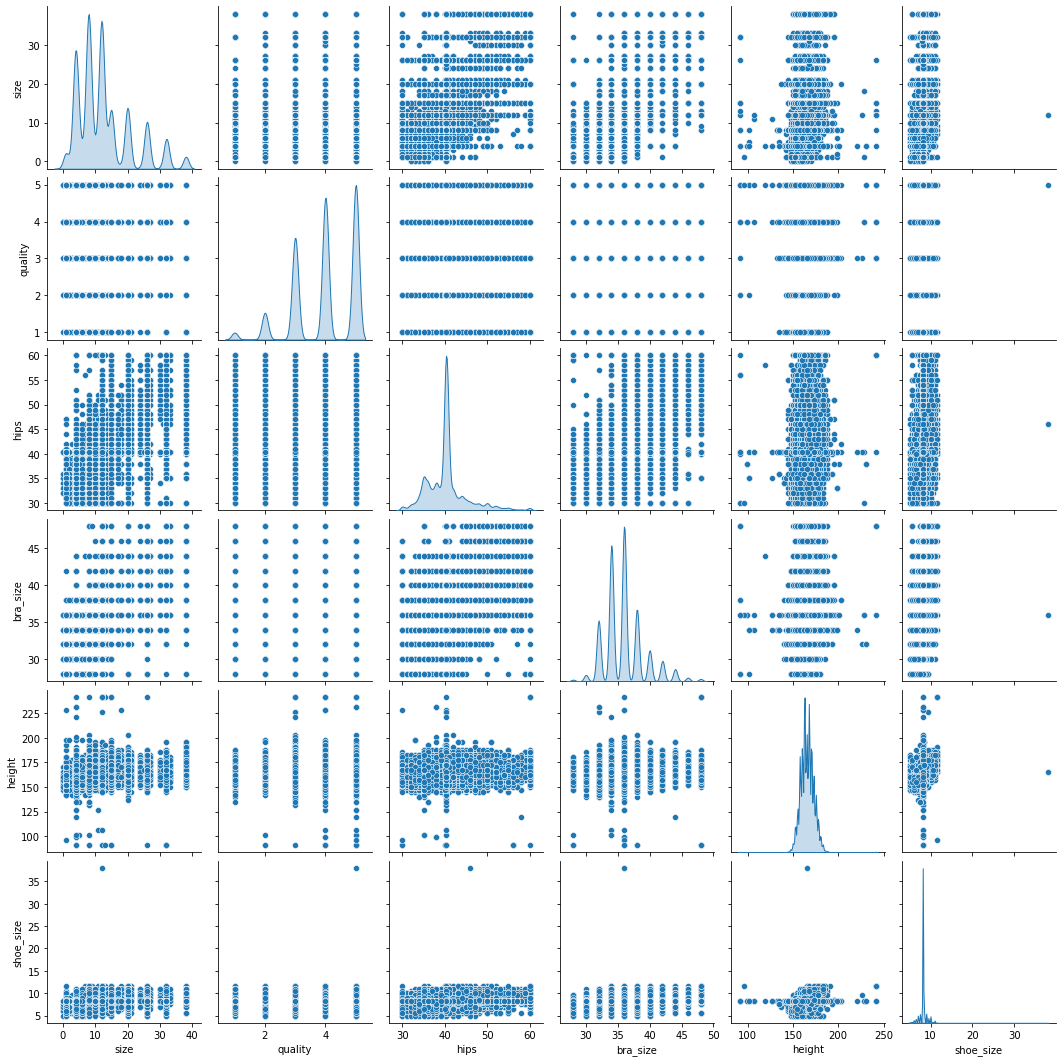

In [32]:
df_num= data1.select_dtypes(include=np.number)
sns.pairplot(df_num,diag_kind='kde')

In [ ]:
The default pairplot shows scatter plots between variables on the upper and lower triangle and histograms 
along the diagonal.


In [ ]:
We can also see that the distribution of hips,bra_size,size is heavily skewed to the right. 


# 1.Statistical Analysis:
1. Test the claim that the category feature and review summary have any relationship among them. The level of significance is 5%.

In [33]:
table= pd.crosstab(data1['review_summary'],data1['category'])
table

category,bottoms,dresses,new,outerwear,sale,tops,wedding
review_summary,,,,,,,
!,1,0,0,0,0,1,0
!!!,0,0,0,0,0,1,0
!!!!,1,0,0,0,0,0,0
#4 for me! I'm collecting,0,0,0,0,0,1,0
#FashionDeux Absolutely,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...
you shouldn't have to spe,0,1,0,0,0,0,0
yup.,0,0,0,0,0,1,0
yup. This coat is amazing,0,0,0,1,0,0,0


In [131]:
chi2_val = round(stats.chi2.isf(q = 0.05, df = 5), 4)

print('Critical value for chi-square test:', chi2_val)

Critical value for chi-square test: 11.0705


In [132]:
test_stat, p, dof, expected_value =chi2_contingency(observed=table,correction=False)

print("Test statistic:", test_stat)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected values:", expected_value)

Test statistic: 428425.0592298971
p-value: 0.0
Degrees of freedom: 370272
Expected values: [[0.3687885  0.4505375  0.51909651 ... 0.06097355 0.49194347 0.00664331]
 [0.18439425 0.22526875 0.25954825 ... 0.03048677 0.24597174 0.00332166]
 [0.18439425 0.22526875 0.25954825 ... 0.03048677 0.24597174 0.00332166]
 ...
 [0.18439425 0.22526875 0.25954825 ... 0.03048677 0.24597174 0.00332166]
 [0.18439425 0.22526875 0.25954825 ... 0.03048677 0.24597174 0.00332166]
 [0.18439425 0.22526875 0.25954825 ... 0.03048677 0.24597174 0.00332166]]


# Q2.Test statistically whether the size and hips have any relationship using 0.05 alpha. Before the above test, Test the normality tes

# Q. 3Does the quality significantly differ for any one shoe width? Test the test with 96%confidence intervals

In [ ]:
𝐻0
 : The quality differ of all shoe_width are the same.

𝐻1
: The quality differ of all shoe_width is not same

In [53]:
stat, p_value = stats.shapiro(data1['quality'])
print('p-value:', p_value)

p-value: 0.0


In [41]:
data1['shoe_width'].unique()

array(['average', 'wide', 'narrow'], dtype=object)

In [43]:
gr_A = data1[data1['shoe_width'] == 'average']['quality']
gr_B = data1[data1['shoe_width'] == 'wide']['quality']
gr_C = data1[data1['shoe_width'] == 'narrow']['quality']

In [45]:
t = data1['shoe_width'].nunique()
print('t:', t)
N = data1['shoe_width'].value_counts().sum()
print('N:', N)

t: 3
N: 82790


In [46]:
f_test, p_val = stats.f_oneway(gr_A,gr_B,gr_C)

print('Test statistic:', f_test)
print('p-value:', p_val)

Test statistic: 2.2965953956192084
p-value: 0.1006071763914662


In [48]:
As P_val < alpha so we reject null hypothesis hence quality differ for one  shoe_width significantly

0.040000000000000036

# 4. Check if the shoe width feature affects the review summary with a 99% confidence interval.

In [55]:
table1= pd.crosstab(data1['review_summary'],data1['shoe_width'])
table1

shoe_width,average,narrow,wide
review_summary,,,
!,2,0,0
!!!,1,0,0
!!!!,1,0,0
#4 for me! I'm collecting,1,0,0
#FashionDeux Absolutely,1,0,0
...,...,...,...
you shouldn't have to spe,1,0,0
yup.,1,0,0
yup. This coat is amazing,1,0,0


In [56]:
chi2_val = round(stats.chi2.isf(q = 0.05, df = 2), 4)

print('Critical value for chi-square test:', chi2_val)

Critical value for chi-square test: 5.9915


In [58]:
test_stat, p, dof, expected_value =chi2_contingency(observed=table1,correction=False)

print("Test statistic:", test_stat)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected values:", expected_value)

Test statistic: 129510.89002085806
p-value: 8.929642565668178e-34
Degrees of freedom: 123424
Expected values: [[1.86689214 0.03749245 0.09561541]
 [0.93344607 0.01874623 0.04780771]
 [0.93344607 0.01874623 0.04780771]
 ...
 [0.93344607 0.01874623 0.04780771]
 [0.93344607 0.01874623 0.04780771]
 [0.93344607 0.01874623 0.04780771]]


In [ ]:
as P-Val is < alpha so we reject null hypothesis and shoe_width and reviw_summary are dependent variable

# 5. Check if the length feature affects the review summary with a 95% confidenceinterval

In [61]:
table2= pd.crosstab(data1['review_summary'],data1['length'])
table2

length,just right,just right,slightly long,slightly short,very long,very short
review_summary,,,,,,
!,0,1,1,0,0,0
!!!,0,1,0,0,0,0
!!!!,0,1,0,0,0,0
#4 for me! I'm collecting,0,1,0,0,0,0
#FashionDeux Absolutely,0,1,0,0,0,0
...,...,...,...,...,...,...
you shouldn't have to spe,0,1,0,0,0,0
yup.,0,1,0,0,0,0
yup. This coat is amazing,0,1,0,0,0,0


In [63]:
test_stat, p, dof, expected_value =chi2_contingency(observed=table2,correction=False)

print("Test statistic:", test_stat)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected values:", expected_value)

Test statistic: 330130.50923448865
p-value: 4.914502572737814e-159
Degrees of freedom: 308560
Expected values: [[8.45512743e-04 1.49641261e+00 2.72037686e-01 1.52651286e-01
  5.86544269e-02 1.93984781e-02]
 [4.22756372e-04 7.48206305e-01 1.36018843e-01 7.63256432e-02
  2.93272134e-02 9.69923904e-03]
 [4.22756372e-04 7.48206305e-01 1.36018843e-01 7.63256432e-02
  2.93272134e-02 9.69923904e-03]
 ...
 [4.22756372e-04 7.48206305e-01 1.36018843e-01 7.63256432e-02
  2.93272134e-02 9.69923904e-03]
 [4.22756372e-04 7.48206305e-01 1.36018843e-01 7.63256432e-02
  2.93272134e-02 9.69923904e-03]
 [4.22756372e-04 7.48206305e-01 1.36018843e-01 7.63256432e-02
  2.93272134e-02 9.69923904e-03]]


In [ ]:
 p_val < alpha so we reject null hypothesis hence length and review summary are dependent variables.

# 6. Does the average quality significantly differ for the different fits? Kindly test the relevant hypothesis test by having 0.05 alpha.
Check the normality of the data before the above test. Alpha = .05

In [65]:
data1['fit'].unique()

array(['small', 'fit', 'large'], dtype=object)

In [66]:
gr_A = data1[data1['fit'] == 'small']['quality']
gr_B = data1[data1['fit'] == 'fit']['quality']
gr_C = data1[data1['fit'] == 'large']['quality']

In [68]:
t = data1['fit'].nunique()
print('t:', t)
N = data1['fit'].value_counts().sum()
print('N:', N)

t: 3
N: 82790


In [71]:
f = round(stats.f.isf(q = 0.05, dfn = 2, dfd =82787 ), 4)
print('Critical value for F-test:', f)

Critical value for F-test: 2.9958


In [73]:
f_test, p_val = stats.f_oneway(gr_A,gr_B,gr_C)

print('Test statistic:', f_test)


Test statistic: 2146.2393752903026


In [ ]:
as t_stat > critical value so we fail to reject null hypothesis hence average quality for different is same.